# A Classical Pharmacokinetic Model

A pharmacokinetic (PK) model is a mathematical description of the absorption, distribution, metabolism, and excretion of a substance by an organism. The figure below shows a schematic representation of a "one-compartment" classical PK model.

![Pharmacokinetic Model](pk1.png)

In this "one-compartment" model, there are actually three "compartments" (represented as rectangular boxes in the figure) for which amounts of substance are tracked as state variables: $A_0$ represents the amount of substance in the "exposure compartment" (e.g., the gut in an oral dosing scenario); $A_1$ represents the amount of substance in the "central compartment" (e.g., in the blood of the organism); and $A_2$ represents the amount that has been cleared from the body (e.g., via metabolism or excretion). Thus,
$$
\begin{align}
  \frac{\textrm{d}}{\textrm{d}t}A_0(t) &= -k_{01} A_0(t), \\
  \frac{\textrm{d}}{\textrm{d}t}A_1(t) &= k_{01} A_0(t) - k_{12} A_1(t), \textrm{ and} \\
  \frac{\textrm{d}}{\textrm{d}t}A_2(t) &= k_{12} A_1(t), \\
\end{align}
$$

where $k_{01}$ is the rate constant (with units of one over time) that, along with the value of $A_0$, determines the rate of delivery of the substance to the body and $k_{12}$ is the rate constant (with units of one over time) that, along with the value of $A_1$, determines the rate of clearance from the body. In addition to the state variables, the model includes an "output" variable, $C$, that represents the concentration in the central compartment. The value of this variable is computed as
$$
\begin{equation}
  C(t) = \frac{A_1(t)}{V_\textrm{d}},
\end{equation}
$$

where $V_\textrm{d}$ is a parameter representing the effective volume of the central compartment, or the "volume of distribution." The model includes another output variable,
$$
\begin{equation}
  A_\textrm{tot}(t) = A_0(t) + A_1(t) + A_2(t),
\end{equation}
$$

that represents the total amount of substance in the system. Finally, the model includes an additional state variable that represents the area under the concentration vs. time curve (AUC), as this is a quantity that is often computed in pharmacokinetic analyses. The AUC for the period from time $0$ to time $t$ is given by $\textrm{AUC}(t) = \int_0^t C(\tau) \, \textrm{d}\tau$ and thus the state equation for this quantity is
$$
\begin{equation}
  \frac{\textrm{d}}{\textrm{d}t} \textrm{AUC}(t) = C(t).
\end{equation}
$$

In order to solve an initial value problem for the classical PK model, one needs to provide the values of the three parameters ($k_{01}$, $k_{12}$, and $V_\textrm{d}$) as well as the initial values of the four state variables ($A_0$, $A_1$, $A_2$, and $\textrm{AUC}$).

## MCSim Model Specification

We used the [GNU MCSim](https://www.gnu.org/software/mcsim/) model specification language to implement the classical PK model. The complete MCSim model specification file for this model, `pk1.model`, can be found in the `extdata` subdirectory of the **PyMCSimMod** package installation directory.

The model specification file uses the text symbols `A0`, `A1`, `A2`, and `AUC` to represent the state variables $A_0$, $A_1$, $A_2$, and $\textrm{AUC}$, respectively, and the text symbols `k01`, `k12`, and `Vd` to represent the parameters $k_{01}$, $k_{12}$, and $V_\textrm{d}$, respectively. In addition, the text symbols `A0_init`, `A1_init`, `A2_init`, and `AUC_init` represent parameters that can be used to set (via the `updateY0` method of the `Model` class) the initial conditions of the state variables.

## Building the Model

First, we load the **PyMCSimMod** package as follows.

In [1]:
%load_ext autoreload
%autoreload 2

from pymcsimmod import create_model

Using the following commands, we create a model object (i.e., an instance of the `ScipyModel` class) using the model specification file `pk1.model` that is included in the **PyMCSimMod** package.

In [2]:
import importlib.resources
with importlib.resources.path('pymcsimmod.data', 'pk1.model') as filename:
    pk1_mod = create_model(filename, backend="scipy")

## Predicting the Blood Concentration of a Substance Following an Oral Dose

Suppose we want to predict the blood concentration of a substance during the 20-hour period following oral ingestion of 200 mg of the substance. Let's assume that the oral absorption rate constant ($k_{01}$) is 0.8 $h^{-1}$, the clearance rate constant ($k_{12}$) is 0.4 $h^{-1}$, and the volume of distribution ($V_\textrm{d}$) is 45 L. We can change the parameter values from their default values (which are given in the model specification file) to the values we wish to use for simulation of this scenario as follows. 

The resulting initial conditions dependent on those parameters are automatically updated.

In [3]:
pk1_mod.update_constants(k01 = 0.8, k12 = 0.4, Vd = 45, A0_init = 200)

print(pk1_mod.parameters)
print(pk1_mod.Y0)

{'A0_init': 200, 'A1_init': 0, 'A2_init': 0, 'AUC_init': 0, 'Vd': 45, 'k01': 0.8, 'k12': 0.4}
{'A0': 200, 'A1': 0, 'A2': 0, 'AUC': 0}


Finally, we can perform a simulation that provides results for the desired output times (i.e., $t = 0, 0.1, 0.2, \ldots, 20.0$) using the following commands.

In [4]:
import numpy as np

# Define output times for simulation.
times = np.arange(start = 0, stop = 20, step = 0.1)

# Run simulation.
results_oral = pk1_mod.run_model(times)
out_oral = results_oral.dataframe

## Examining the Results

The command shown above, `results_oral = pk1_mod.run_model(times)`, performs a model simulation while `out_oral = results_oral.dataframe` stores the simulation results in a pandas daframe called `out_oral`. There is one row for each output time, and one column for time and each state variable and each output variable. The first five rows of this data structure are shown below. Note that the independent variable, which is $t$ in the case of the classical PK model, is always labeled "time" in the output data structure.

In [5]:
display(out_oral.head())

,time,A0,A1,A2,AUC,C,Atot
0,0.0,200.000000,0.000000,0.000000,0.000000,0.000000,200.000000
1,0.1,184.623275,15.069226,0.307500,0.017083,0.334872,200.000000
2,0.2,170.429031,28.388513,1.182456,0.065692,0.630856,200.000000
3,0.3,157.326019,40.116199,2.557783,0.142099,0.891471,200.000001
4,0.4,145.230061,50.397449,4.372492,0.242916,1.119943,200.000002


We can examine the parameter values and initial conditions that were used for this simulation using the following commands.

In [6]:
print(pk1_mod.parameters)
print(pk1_mod.Y0)

{'A0_init': 200, 'A1_init': 0, 'A2_init': 0, 'AUC_init': 0, 'Vd': 45, 'k01': 0.8, 'k12': 0.4}
{'A0': 200, 'A1': 0, 'A2': 0, 'AUC': 0}


Finally, we can create a visual representation of the simulation results. For example, we can plot the concentration vs. time using the following commands.

<Axes: xlabel='Time (h)', ylabel='Concentration (mg/L)'>

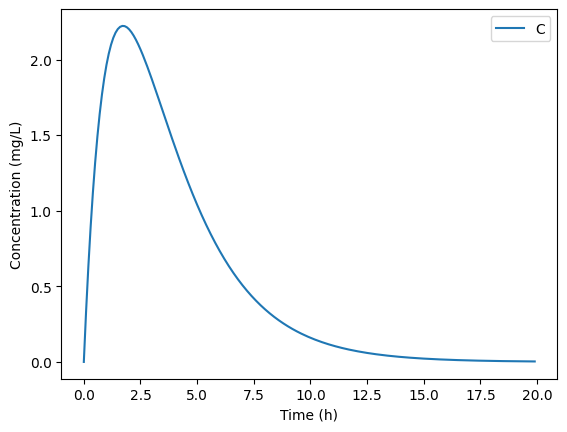

In [7]:
results_oral.plot_results(variables='C', xlabel='Time (h)', ylabel='Concentration (mg/L)')

## Predicting the Blood Concentration of a Substance Following an IV Dose

Suppose we want to predict the blood concentration of a substance during the 20-hour period following an intravenous (IV) injection of 200 mg of the substance. Let's assume the same clearance rate constant ($k_{12} = 0.4 \, \textrm{h}^{-1}$) and volume of distribution ($V_\textrm{d} = 45 \, \textrm{L}$) as we used for the oral exposure scenario. (The value of the absorption rate constant, $k_{01}$, won't matter because there will never be any substance in the exposure compartment.) We can change the parameter values from their default values to the values we wish to use for simulation of this scenario as follows.

In [8]:
pk1_mod.update_constants(k12 = 0.4, Vd = 45, A0_init = 0, A1_init = 200, reset_to_defaults=True)
print(pk1_mod.parameters)
print(pk1_mod.Y0)

{'A0_init': 0, 'A1_init': 200, 'A2_init': 0, 'AUC_init': 0, 'Vd': 45, 'k01': 1, 'k12': 0.4}
{'A0': 0, 'A1': 200, 'A2': 0, 'AUC': 0}


(**Note** that $k_{01}$ was assigned its default value of 1.0 because `update_constants(reset_to_defaults=True)` was used which resets all parameters and intial conditions back to the defaults from the .model file and only updates the desired parameters.)

We can perform a simulation that provides results for the desired output times (i.e., $t = 0, 0.1, 0.2, \ldots, 20.0$) using the following commands.

<Axes: xlabel='Time (h)', ylabel='Concentration (mg/L)'>

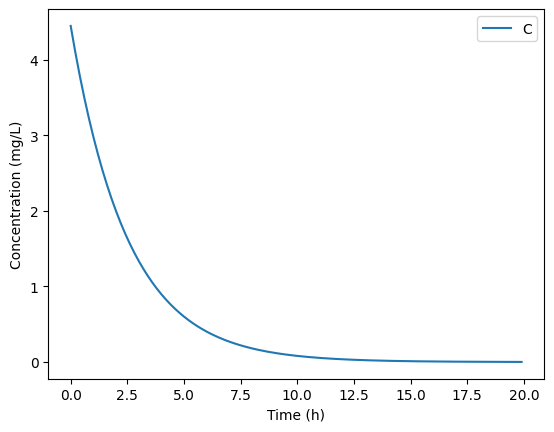

In [9]:
# Run simulation.
results_IV = pk1_mod.run_model(times)
out_IV = results_IV.dataframe
results_IV.plot_results(variables='C', xlabel='Time (h)', ylabel='Concentration (mg/L)')


We can create a visual representation of the simulation results for both the oral dosing and IV dosing scenarios using the following commands.

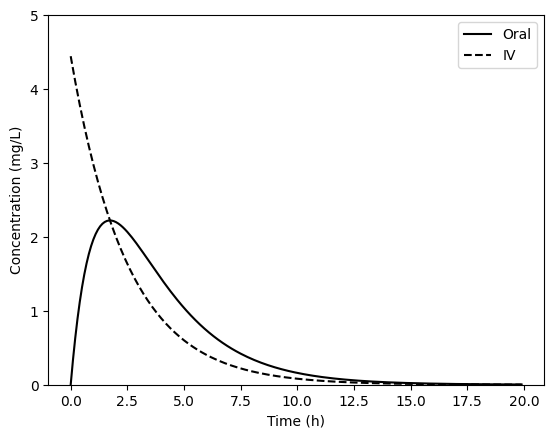

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1)
ax.plot(out_oral['time'], out_oral['C'], 'k-', label='Oral')
ax.plot(out_IV['time'], out_IV['C'], 'k--', label='IV')
ax.set_ylim([0, 5])
ax.set_xlabel('Time (h)')
ax.set_ylabel('Concentration (mg/L)')
ax.legend(loc='best')


## Comparing AUC Values for Oral and IV Dosing Scenarios

Because the PK model we're using assumes that 100% of the substance in the exposure compartment (i.e., $A_0$) will eventually be transferred to the central compartment (i.e., 100% bioavailability for the oral exposure scenario) and 100% of an IV dose is delivered directly to the central compartment, the AUCs (at $t = \infty$) for the oral and IV exposure scenarios should be equal. We can verify that the AUCs at $t = 20$ hours (by which time most of the substance has been cleared) for both scenarios are approximately equal by examining the value of the $\textrm{AUC}$ output variable in the final row of the respective output matrices.

In [11]:
# display last value of 'AUC' in out_oral
print(f"AUC (oral): {out_oral['AUC'].iloc[-1]:.05f}")
print(f"AUC (IV): {out_IV['AUC'].iloc[-1]:.05f}")

AUC (oral): 11.10357
AUC (IV): 11.10724
